In [6]:
from baselines.Custom import ippo_ff_mpe, ippo_rnn_mpe, mappo_rnn_mpe
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"

from IPython.display import HTML, display


import jax
import jax.numpy as jnp
import flax
import numpy as np
from matplotlib import animation
from IPython.display import HTML, display
import jaxmarl
from jaxmarl.environments.mpe.simple_spread import SimpleSpreadMPE
from jaxmarl.wrappers.baselines import MPELogWrapper
from baselines.Custom.ippo_rnn_mpe import ActorCriticRNN, ScannedRNN 



In [7]:
import jax
import jaxlib
import flax

print(jax.devices())
print("JAX version:", jax.__version__)
print("JAXlib version:", jaxlib.__version__)
print("Flax version:", flax.__version__)


[CudaDevice(id=0)]
JAX version: 0.4.38
JAXlib version: 0.4.38
Flax version: 0.10.1


In [8]:
algo_and_config_map = {
    "ippo_ff_mpe": (ippo_ff_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_ff_mpe_simple_spread.yaml")),
    "ippo_rnn_mpe": (ippo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_rnn_mpe_simple_spread.yaml")),
    "mappo_rnn_mpe": (mappo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "mappo_rnn_mpe_simple_spread.yaml"))
}

In [9]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

CPU times: user 4 μs, sys: 2 μs, total: 6 μs
Wall time: 20 μs


In [ ]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]
config['TOTAL_TIMESTEPS'] = 100000
config["ENV_KWARGS"] = {}

CPU times: user 548 μs, sys: 0 ns, total: 548 μs
Wall time: 614 μs


In [11]:
config

{'ENV_NAME': 'MPE_simple_spread_v3', 'LR': 0.0005, 'NUM_ENVS': 16, 'NUM_STEPS': 128, 'FC_DIM_SIZE': 128, 'GRU_HIDDEN_DIM': 128, 'TOTAL_TIMESTEPS': 10000, 'UPDATE_EPOCHS': 4, 'NUM_MINIBATCHES': 2, 'GAMMA': 0.99, 'GAE_LAMBDA': 0.95, 'CLIP_EPS': 0.3, 'SCALE_CLIP_EPS': False, 'ENT_COEF': 0.01, 'VF_COEF': 1.0, 'MAX_GRAD_NORM': 0.5, 'ACTIVATION': 'tanh', 'ANNEAL_LR': True, 'SEED': 30, 'ENV_KWARGS': {}, 'ENTITY': 'emiecz-princeton', 'PROJECT': 'ScalingLaws', 'WANDB_MODE': 'offline', 'RUN_NAME': 'ippo-rnn-simple-spread'}

In [12]:
import time
for num_agents in range(3,5):
    for num_landmarks in range(3,5):
        start = time.time()
        config["ENV_KWARGS"]["num_agents"] = num_agents
        config["ENV_KWARGS"]["num_landmarks"] = num_landmarks
        config['RUN_NAME'] = f"ippo-rnn-simple-spread_{num_landmarks}_landmarks_{num_agents}_agents" 
        
        print(f"Running MPE Training with run name {config['RUN_NAME']}, and config {config['ENV_KWARGS']}")
        out = algo.main(config)
        print(f"Finished in {time.time()-start}")

Running MPE Training with run name ippo-rnn-simple-spread_3_landmarks_3_agents, and config {'num_agents': 3, 'num_landmarks': 3}


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


actor_loss,▁▅██
approx_kl,█▆▄▁
clip_frac,▁▁▁▁
entropy,█▆▃▁
env_step,▁▃▆█
ratio,▅█▁▇
ratio_0,▁▁▁▁
returns,▄▁▄█
total_loss,█▆▃▁
value_loss,█▆▃▁
actor_loss,-6e-05


Finished in 50.46260452270508
Running MPE Training with run name ippo-rnn-simple-spread_4_landmarks_3_agents, and config {'num_agents': 3, 'num_landmarks': 4}


actor_loss,▁▅▇█
approx_kl,█▅▃▁
clip_frac,▁▁▁▁
entropy,█▆▃▁
env_step,▁▃▆█
ratio,▅█▁▆
ratio_0,▁▁▁▁
returns,█▁██
total_loss,█▇▃▁
value_loss,█▇▃▁
actor_loss,2e-05


Finished in 30.760072708129883
Running MPE Training with run name ippo-rnn-simple-spread_3_landmarks_4_agents, and config {'num_agents': 4, 'num_landmarks': 3}


actor_loss,▁▆▆█
approx_kl,█▄▄▁
clip_frac,▁▁▁▁
entropy,█▅▃▁
env_step,▁▃▆█
ratio,█▆▅▁
ratio_0,▁▁▁▁
returns,▂▁██
total_loss,█▄▂▁
value_loss,█▄▂▁
actor_loss,-2e-05


Finished in 42.16066575050354
Running MPE Training with run name ippo-rnn-simple-spread_4_landmarks_4_agents, and config {'num_agents': 4, 'num_landmarks': 4}


actor_loss,▁▅▇█
approx_kl,█▇▄▁
clip_frac,▁▁▁▁
entropy,█▆▃▁
env_step,▁▃▆█
ratio,█▃▄▁
ratio_0,█▆▅▁
returns,▁▆█▄
total_loss,█▃▁▁
value_loss,█▃▁▁
actor_loss,-0.0


Finished in 33.69456100463867


# Evaluation Metrics

## Key Metrics to Consider:

1. **Average Episode Return**: Total reward accumulated per episode
2. **Success Rate**: For simple_spread, this could be % of episodes where all agents reach landmarks
3. **Episode Length**: How long episodes last (shorter might be better if task is solved quickly)
4. **Collision Rate**: How often agents collide with each other
5. **Min/Max Returns**: Variance shows robustness

## Training vs Evaluation Returns:

- **Training returns** include exploration noise (epsilon-greedy or entropy)
- **Evaluation returns** should use deterministic/greedy actions (take argmax or mean of policy)
- More episodes = more reliable estimate

**Recommendation**: Run a proper evaluation with ~100 episodes using greedy actions on fresh seeds.

In [8]:
from baselines.Custom.ippo_rnn_mpe import plot_simulation
from baselines.Custom.ippo_rnn_mpe import load_params_from_path
params, env_config = load_params_from_path("wandb/offline-run-20251111_203514-x2izm05i/files")
#plot_simulation(saved_path="wandb/offline-run-20251111_203514-x2izm05i/files", max_steps=50, num_episodes=2, seed=123)

Loading model parameters from: wandb/offline-run-20251111_203514-x2izm05i/files/final_model_params.msgpack
Loading environment config from: wandb/offline-run-20251111_203514-x2izm05i/files/env_config.json


In [9]:
%%time
from baselines.Custom.ippo_rnn_mpe import evaluate_policy
eval_metrics, returns, lengths = evaluate_policy(params, env_config, num_eval_episodes=5, max_steps=20)

print("\n" + "="*70)
print("EVALUATION RESULTS (Greedy/Deterministic Actions)")
print("="*70)
print(f"Mean Return:        {eval_metrics['mean_return']:.2f} ± {eval_metrics['std_return']:.2f}")
print(f"Median Return:      {eval_metrics['median_return']:.2f}")
print(f"Min/Max Return:     {eval_metrics['min_return']:.2f} / {eval_metrics['max_return']:.2f}")
print(f"Mean Episode Len:   {eval_metrics['mean_episode_length']:.1f} ± {eval_metrics['std_episode_length']:.1f}")
print("="*70)

Starting evaluation episode 1/5...
Starting evaluation episode 2/5...
Starting evaluation episode 3/5...
Starting evaluation episode 4/5...
Starting evaluation episode 5/5...

EVALUATION RESULTS (Greedy/Deterministic Actions)
Mean Return:        -155.57 ± 36.47
Median Return:      -168.36
Min/Max Return:     -198.30 / -110.59
Mean Episode Len:   20.0 ± 0.0
CPU times: user 1min 5s, sys: 4.43 s, total: 1min 9s
Wall time: 59.4 s


In [13]:
from pathlib import Path
from baselines.Custom.ippo_rnn_mpe import load_params_from_path
import re

# Find all agent-landmark configuration folders
base_path = Path("ippo_rnn_mpe-offline")
pattern = re.compile(r"agents(\d+)-landmarks(\d+)")

# Dictionary to store all loaded models
loaded_models = {}

if base_path.exists():
    for config_folder in sorted(base_path.iterdir()):
        if config_folder.is_dir():
            match = pattern.match(config_folder.name)
            if match:
                num_agents = int(match.group(1))
                num_landmarks = int(match.group(2))
                
                # Look for wandb/latest-run
                wandb_path = config_folder / "wandb" / "latest-run"
                
                if wandb_path.exists():
                    try:
                        # Load params and config
                        params, env_config = load_params_from_path(wandb_path)
                        
                        # Store in dictionary with tuple key
                        key = (num_agents, num_landmarks)
                        loaded_models[key] = {
                            'params': params,
                            'env_config': env_config,
                            'path': str(wandb_path)
                        }
                        
                        print(f"✓ Loaded model: {num_agents} agents, {num_landmarks} landmarks")
                    except Exception as e:
                        print(f"✗ Failed to load {config_folder.name}: {e}")
                else:
                    print(f"✗ No wandb/latest-run found in {config_folder.name}")
    
    print(f"\n{'='*70}")
    print(f"Total models loaded: {len(loaded_models)}")
    print(f"Configurations: {sorted(loaded_models.keys())}")
    print(f"{'='*70}")
else:
    print(f"Error: {base_path} directory not found")

Loading model parameters from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents3-landmarks3/wandb/offline-run-20251111_221457-uqg7lqi2/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents3-landmarks3/wandb/offline-run-20251111_221457-uqg7lqi2/files/env_config.json
✓ Loaded model: 3 agents, 3 landmarks
Loading model parameters from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents3-landmarks4/wandb/offline-run-20251111_221547-raazo2i7/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents3-landmarks4/wandb/offline-run-20251111_221547-raazo2i7/files/env_config.json
✓ Loaded model: 3 agents, 4 landmarks
Loading model parameters from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents4-landmarks3/wandb/offline-run-20251111_221618-vnhdrp1d/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_rnn_mpe-offline/agents4-landmarks3/wandb/of

In [17]:
from baselines.Custom.ippo_rnn_mpe import evaluate_policy
evaluated_models = {}
for key, value in loaded_models.items():
    eval_metrics, returns, lengths = evaluate_policy(value['params'], value['env_config'], num_eval_episodes=5, max_steps=40)
    evaluated_models[key] = {
        'eval_metrics': eval_metrics,
        'returns': returns,
        'lengths': lengths
    }

Starting evaluation episode 1/5...
Starting evaluation episode 2/5...
Starting evaluation episode 3/5...
Starting evaluation episode 4/5...
Starting evaluation episode 5/5...
Starting evaluation episode 1/5...
Starting evaluation episode 2/5...
Starting evaluation episode 3/5...
Starting evaluation episode 4/5...
Starting evaluation episode 5/5...
Starting evaluation episode 1/5...
Starting evaluation episode 2/5...
Starting evaluation episode 3/5...
Starting evaluation episode 4/5...
Starting evaluation episode 5/5...
Starting evaluation episode 1/5...
Starting evaluation episode 2/5...
Starting evaluation episode 3/5...
Starting evaluation episode 4/5...
Starting evaluation episode 5/5...


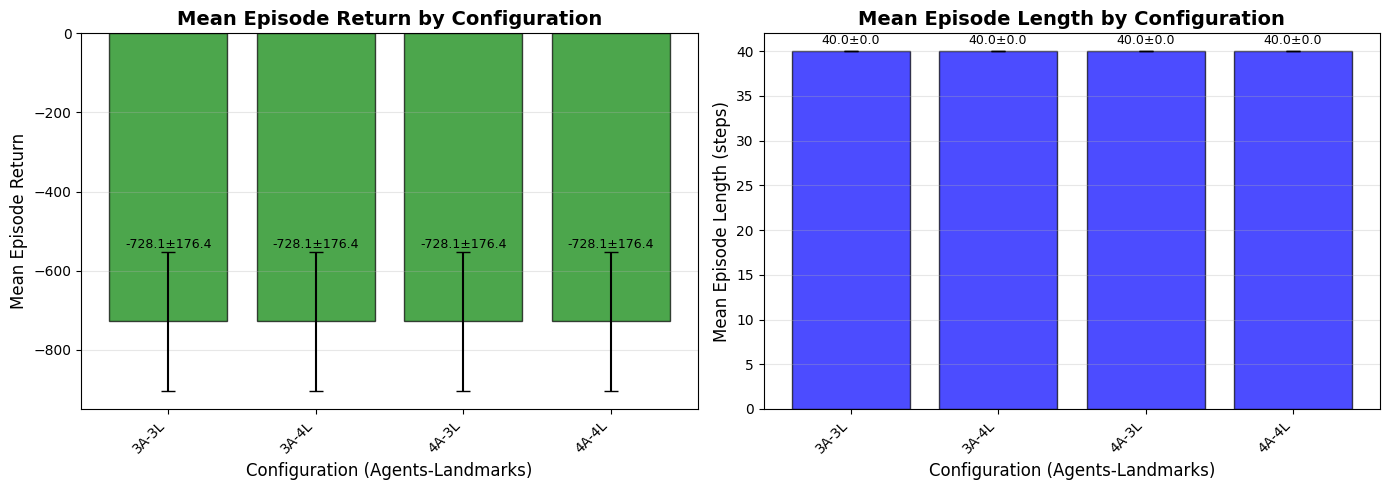


EVALUATION SUMMARY
Config          Mean Return          Mean Episode Length      
--------------------------------------------------------------------------------
3A-3L           -728.07 ± 176.41         40.0 ± 0.0
3A-4L           -728.07 ± 176.41         40.0 ± 0.0
4A-3L           -728.07 ± 176.41         40.0 ± 0.0
4A-4L           -728.07 ± 176.41         40.0 ± 0.0


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
configs = sorted(evaluated_models.keys())
mean_returns = [evaluated_models[k]['eval_metrics']['mean_return'] for k in configs]
std_returns = [evaluated_models[k]['eval_metrics']['std_return'] for k in configs]
mean_lengths = [evaluated_models[k]['eval_metrics']['mean_episode_length'] for k in configs]
std_lengths = [evaluated_models[k]['eval_metrics']['std_episode_length'] for k in configs]

# Create labels for x-axis
labels = [f"{agents}A-{landmarks}L" for agents, landmarks in configs]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Return with error bars
x_pos = np.arange(len(labels))
ax1.bar(x_pos, mean_returns, yerr=std_returns, capsize=5, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Configuration (Agents-Landmarks)', fontsize=12)
ax1.set_ylabel('Mean Episode Return', fontsize=12)
ax1.set_title('Mean Episode Return by Configuration', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(mean_returns, std_returns)):
    ax1.text(i, mean + std + 0.5, f'{mean:.1f}±{std:.1f}', 
             ha='center', va='bottom', fontsize=9)

# Plot 2: Mean Episode Length with error bars
ax2.bar(x_pos, mean_lengths, yerr=std_lengths, capsize=5, alpha=0.7, color='blue', edgecolor='black')
ax2.set_xlabel('Configuration (Agents-Landmarks)', fontsize=12)
ax2.set_ylabel('Mean Episode Length (steps)', fontsize=12)
ax2.set_title('Mean Episode Length by Configuration', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(mean_lengths, std_lengths)):
    ax2.text(i, mean + std + 0.5, f'{mean:.1f}±{std:.1f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)
print(f"{'Config':<15} {'Mean Return':<20} {'Mean Episode Length':<25}")
print("-"*80)
for key in configs:
    agents, landmarks = key
    metrics = evaluated_models[key]['eval_metrics']
    print(f"{agents}A-{landmarks}L{'':<10} "
          f"{metrics['mean_return']:.2f} ± {metrics['std_return']:.2f}{'':<8} "
          f"{metrics['mean_episode_length']:.1f} ± {metrics['std_episode_length']:.1f}")
print("="*80)

In [20]:
mean_returns

[-728.0668701171875,
 -728.0668701171875,
 -728.0668701171875,
 -728.0668701171875]